In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tools.utils import *
import pandas as pd
import numpy as np
import seaborn as sns
from itertools import combinations
from collections import Counter
from pathlib import Path
from sklearn.cluster import KMeans
from scipy.interpolate import interp1d
import scipy.spatial as sp
from matplotlib import pyplot as plt
sns.set()

In [3]:
processed_data_dir = Path('processed_data/tous')

In [4]:
embeddings = np.loadtxt(processed_data_dir / 'embedding.tsv')
metadata = pd.read_csv(processed_data_dir / 'metadata.tsv',sep='\t')
print(len(embeddings), len(metadata))
# 84621 84621

233880 233880


In [5]:
metadata.columns

Index(['platform', 'year', 'sentence', 'sentence_processed'], dtype='object')

In [6]:
metadata.platform.nunique()

50

In [7]:
metadata.drop_duplicates(subset=['platform', 'year', 'sentence'], inplace=True)
metadata.shape

(223464, 4)

# Compare two contracts 

Based on the platform name and date

In [8]:
metadata.platform.value_counts()

platform
paypal         40090
venmo          26126
gofundme       12051
yahoo          11798
uber            7869
ebay            7487
grindr          7177
playstation     6905
canva           6562
match           6285
mint            5663
lyft            4867
twitch          4383
fb              4305
bumble          4025
zoom            3902
shein           3821
capcut          3236
tumblr          3231
snapchat        3186
wechat          2928
amazon          2851
linkedin        2842
spotify         2782
meetup          2645
fitbit          2514
myspace         2467
reddit          2418
grok            2105
hinge           2056
discord         1980
twitter         1838
kickstarter     1836
claude          1750
jasper          1703
youtube         1636
pinterest       1531
nextdoor        1520
google          1432
tinder          1422
tiktok          1225
chatgpt         1176
mistral         1160
instagram       1065
personalai       862
faceapp          791
inflection       702
what

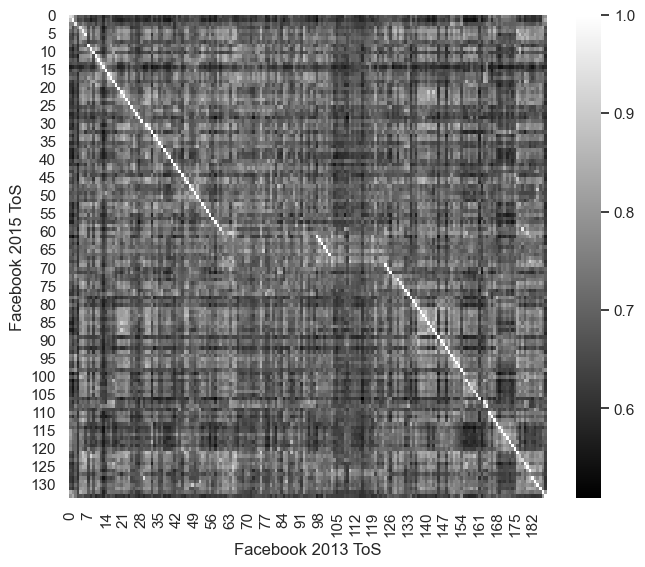

In [9]:
platform_1 = 'twitter'
platform_2 = 'twitter'
year_1 = 20160101
year_2 = 20160901

platform_1 = 'fb'
platform_2 = 'fb'
year_1 = 20131101 # 20180401 #2013110
year_2 = 20150101 #20150101 20190701

# platform_1 = 'Google'
# platform_2 = 'Google'
# year_1 =20051101 #20051101
# year_2 = 20070401 #20070401



idx_1 = list(metadata[(metadata.platform==platform_1) & (metadata.year ==year_1)].index)
idx_2 = list(metadata[(metadata.platform==platform_2) & (metadata.year ==year_2)].index)
#mult = cosine_similarity(embeddings[idx_1,:],embeddings[idx_2,:])
mult = 1 - sp.distance.cdist(embeddings[idx_2,:], embeddings[idx_1,:], 'cosine')
sns.set(rc={'figure.figsize':(7.7,6.27)})
heatmap = sns.heatmap(mult, cmap='gray')
plt.ylabel('Facebook 2015 ToS')
plt.xlabel('Facebook 2013 ToS')
fig = heatmap.get_figure()
fig.savefig("figures/jels/Figure_5_gray.png", dpi=300, bbox_inches='tight') 

In [10]:
len(idx_1), len(idx_2), mult.shape

(188, 134, (134, 188))

In [24]:
print(sum(mult.max(axis=0) > 0.93), sum(mult.max(axis=0) < 0.93))
print(sum(mult.max(axis=1) < 0.93),sum(mult.max(axis=1) >= 0.93))


123 65
13 121


/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_8022/2280298480.py:1: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = pd.Series(mult.max(axis=0)).plot(ylim=(0,1.02), color='black', cmap='gray')
/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_8022/2280298480.py:1: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = pd.Series(mult.max(axis=0)).plot(ylim=(0,1.02), color='black', cmap='gray')


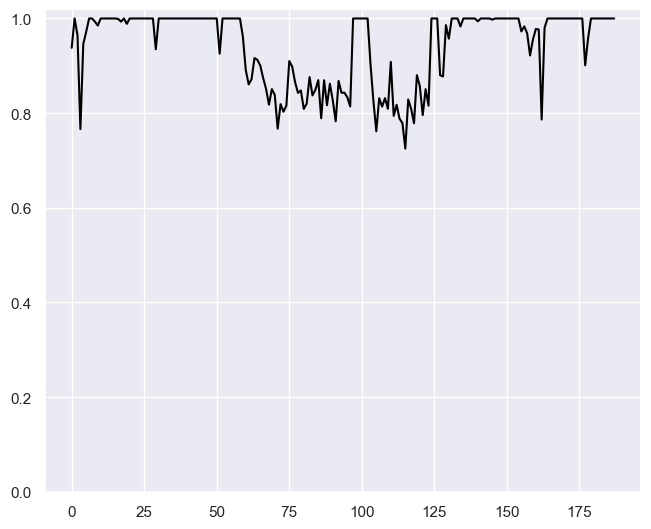

In [36]:
ax = pd.Series(mult.max(axis=0)).plot(ylim=(0,1.02), color='black', cmap='gray')
#ax.axhline(0.93, c='r')
fig = ax.get_figure()
fig.savefig("figures/jels/Figure_6_gray.png", dpi=300, bbox_inches='tight')

In [338]:
# metadata['year'] = metadata.year.apply(lambda x: str(x)[:4] + "0101").astype(int)
# metadata.dropna(subset=['platform','sentence_processed','year'], inplace=True)
# metadata.shape

In [339]:
# metadata['year_int'] = metadata.year.apply(lambda x: str(x)[:4]).astype(int)
# platform_last_yearly = metadata.groupby(['platform','year_int'])['year'].unique().apply(lambda x: x[0]).reset_index()[['platform','year']]
# metadata = metadata.merge(platform_last_yearly[['platform', 'year']], on=['platform', 'year'], how='inner')
# metadata

In [38]:
platforms = ['twitter','fb','instagram']
#platforms = ['google']#,'youTube']
#platforms = ['PayPal','Venmo']
threshold = .93
result_df = compare_timelines(metadata, embeddings,platforms,threshold)

100%|██████████| 7/7 [00:00<00:00, 40.42it/s]


In [39]:
result_df.replace({'platform': {'fb':'Facebook',
                             'twitter':'Twitter',
                             'instagram':'Instagram',}}, inplace=True)

/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


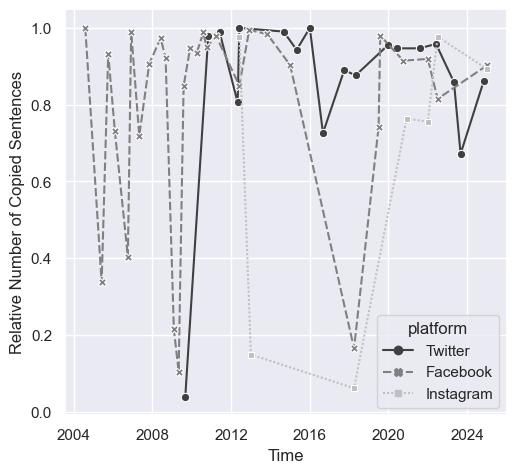

In [46]:
result_df = result_df[(result_df.copied != 592 )& (result_df.index != 'Facebook')]

sns.set(rc={'figure.figsize':(5.7,5.27)})
ax = sns.lineplot(x=result_df.index,y='rel_copied',
                hue='platform',
                style="platform",
                markers=True,
                data=result_df,
                palette='gray'
            )

ax.set(
    xlabel="Time",
    ylabel="Relative Number of Copied Sentences",
)
 
fig = ax.get_figure()
fig.savefig("figures/jels/Figure_8_right_gray.png", dpi=300, bbox_inches='tight')

/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


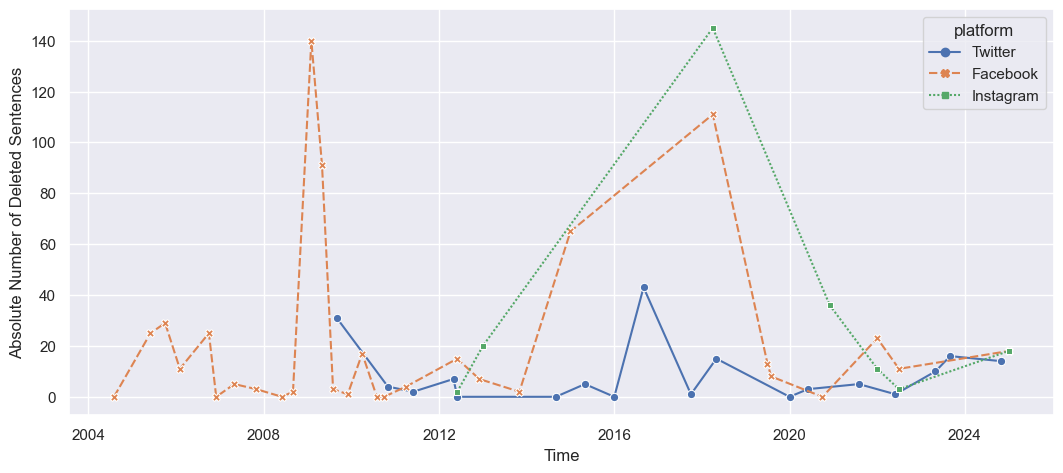

In [50]:
sns.set(rc={'figure.figsize':(12.7,5.27)})
ax =sns.lineplot(x=result_df.index,
                y='deletions',
                hue='platform',
                style="platform",
                markers=True,
                data=result_df,
                #palette='gray'
            )

ax.set(
    xlabel="Time",
    ylabel="Absolute Number of Deleted Sentences",
)

fig = ax.get_figure()
fig.savefig("figures/jels/Figure_9_top.png", dpi=300, bbox_inches='tight')

In [251]:
result_df.columns

Index(['copied', 'deletions', 'additions', 'length', 'length_t_min_1',
       'length_diff', 'future_projection', 'past_projection', 'matrix',
       'platform', 'rel_copied', 'rel_added', 'rel_additions', 'rel_deletions',
       'time', 'year'],
      dtype='object')

/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


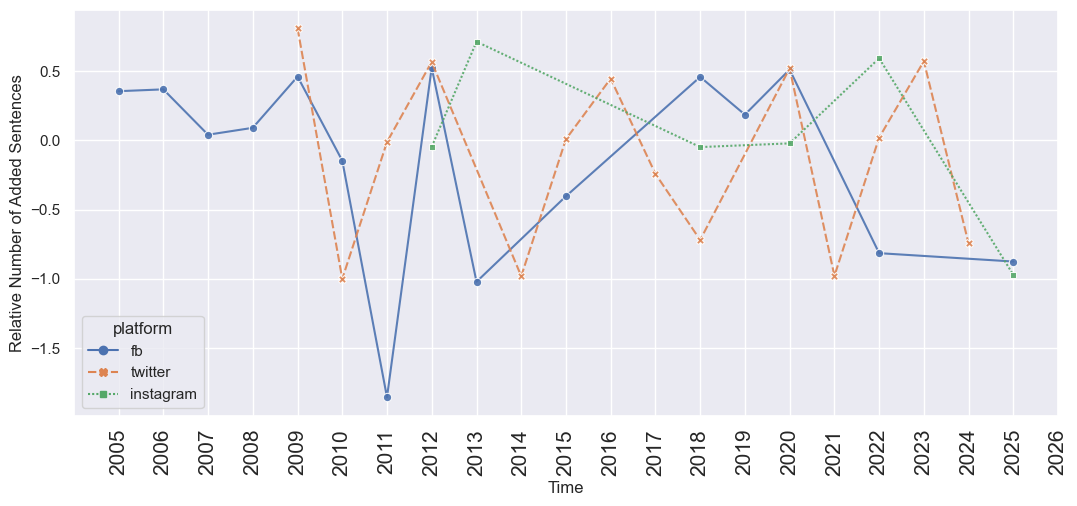

In [259]:
result_df = result_df.sort_index(ascending=True)

sns.set(rc={'figure.figsize':(12.7,5.27)})
result_df['time'] = result_df.index.copy()
result_df['time'] = result_df['time'].apply(lambda x: datetime(int(str(x)[:4]), 1, 1))

ax = sns.lineplot(x='time',y='rel_added',
                hue='platform',
                style="platform",
                markers=True,
                
                data=result_df,
                alpha=.9

            )
ax.set(
    xlabel="Time",
    ylabel="Relative Number of Added Sentences",
)

# platforms_col = [('blue','fb'),('darkorange','twitter'),('green','instagram')]#,'google']#,'youTube']#,'PayPal','Venmo']
# for i,(col,p) in enumerate(platforms_col):
#         for xc in metadata[metadata.platform==p].year.unique():
#          if datetime(int(str(xc)[:4]), 1, 1) >=  result_df.time.min() and datetime(int(str(xc)[:4]), 1, 1) <= result_df.time.max():
#              ax.axvline(x=datetime(int(str(xc)[:4]), 1, 1)+pd.Timedelta(days=i*30), color=col, linestyle='-', alpha=.5, linewidth=2.5)
#         #ax.axvline(x=xc, color=col, linestyle='--', alpha=.2)
# # 👇 Show fewer ticks (e.g., one per year)
# import matplotlib.dates as mdates

ax.xaxis.set_major_locator(mdates.YearLocator(1))   # every 1 year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=90, labelsize=15)

0.0012611026527632563

In [180]:
result_df['time'].iloc[0],pd.Timestamp(datetime(int(str(xc)[:4]), 1, 1))

(Timestamp('2005-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00'))

In [161]:
from datetime import datetime, time 
dt = datetime.combine(result_df.index.min(), time())
dt

datetime.datetime(2005, 1, 1, 0, 0)

In [92]:
result_df_without_min = result_df[result_df.rel_added > result_df.rel_added.min()]

/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='rel_added'>

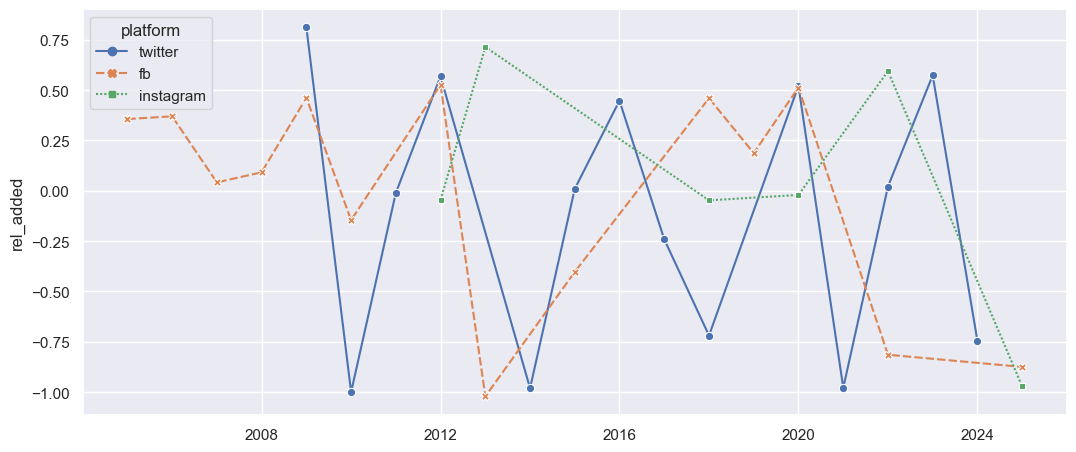

In [93]:
sns.set(rc={'figure.figsize':(12.7,5.27)})
sns.lineplot(x=result_df_without_min.index,
                y='rel_added',
                hue='platform',
                style="platform",
                markers=True,
                data=result_df_without_min
            )

In [51]:
platforms = list(metadata.platform.unique())
threshold = .93
result_df = compare_timelines(metadata, embeddings, platforms,threshold)


100%|██████████| 35/35 [00:03<00:00, 11.61it/s]


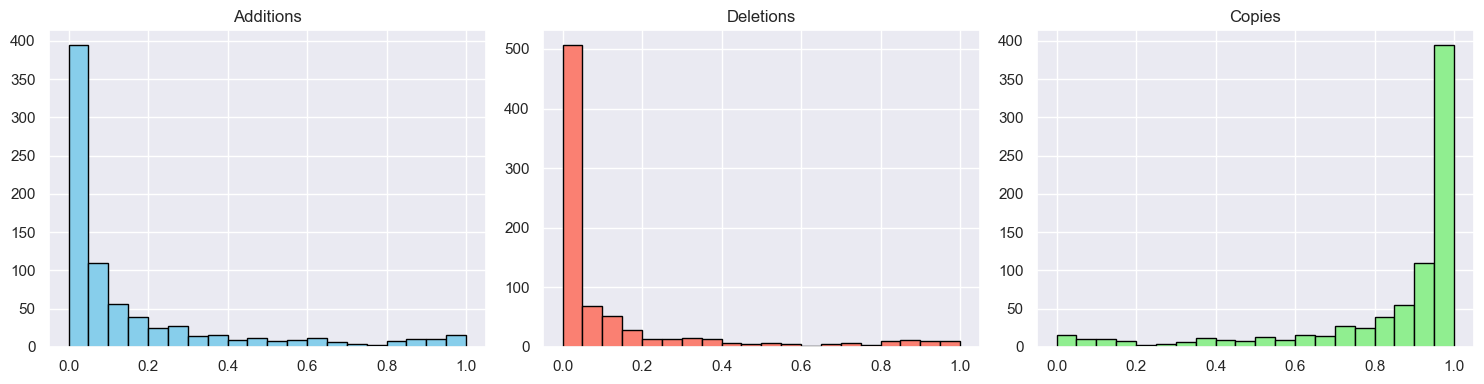

In [52]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = np.linspace(0, 1, 21)
# Plot histograms for each column
axes[0].hist(result_df["rel_additions"], bins=20, color="skyblue", edgecolor="black")
axes[0].set_title("Additions")

axes[1].hist(result_df["rel_deletions"], bins=20, color="salmon", edgecolor="black")
axes[1].set_title("Deletions")

axes[2].hist(result_df["rel_copied"], bins=20, color="lightgreen", edgecolor="black")
axes[2].set_title("Copies")

plt.tight_layout()
plt.show()

In [53]:
import numpy as np
bins = np.linspace(0, 1, 21)
counts, divisions = np.histogram(result_df.rel_deletions, bins=bins) # rel_additions

In [54]:
print((counts / sum(counts)).round(2))
print((counts[divisions[1:] > 0.5] / sum(counts)).round(2).sum())

[0.65 0.09 0.07 0.04 0.02 0.02 0.02 0.02 0.01 0.01 0.01 0.01 0.   0.01
 0.01 0.   0.01 0.02 0.01 0.01]
0.09


In [55]:
result_df['year'] = [i.year for i in result_df.index]

In [56]:
result_df['additions'] +  result_df['copied'] == result_df['length']

2011-01-01    True
2011-12-01    True
2012-07-01    True
2012-09-01    True
2013-05-01    True
              ... 
2024-05-01    True
2024-07-01    True
2024-09-01    True
2025-06-01    True
2025-10-01    True
Length: 784, dtype: bool

In [57]:
result_df.deletions.mean()

23.598214285714285

In [58]:
result_df.additions.mean()

37.141581632653065

In [59]:
result_df = result_df[result_df.deletions < 500]

In [60]:
result_df['plasticity'] = result_df['additions'] + result_df['deletions']
#result_df['plasticity_rel'] = result_df['plasticity'] / result_df['copied']

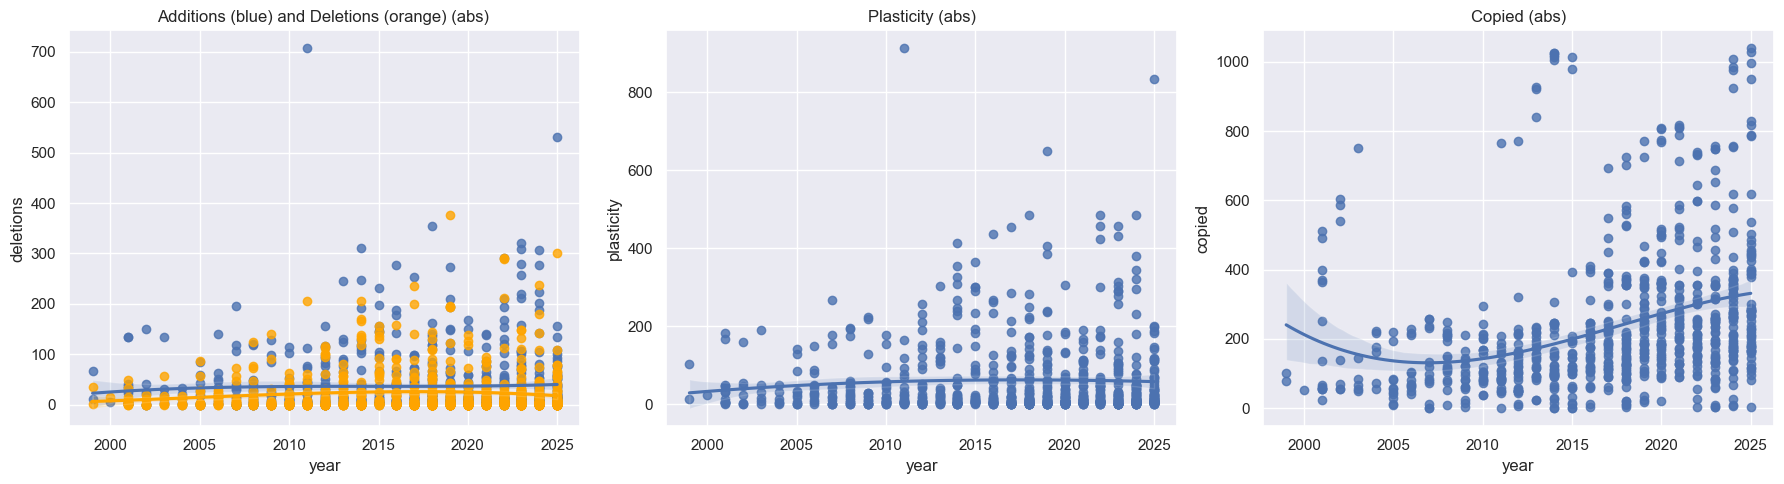

In [61]:
import matplotlib.pyplot as plt
order = 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=result_df.astype({'year': int, 'additions': float}), x='year', y='additions', ax=axes[0],order=order)
sns.regplot(data=result_df.astype({'year': int, 'deletions': float}), x='year', y='deletions', ax=axes[0], color='orange',order=order)
axes[0].set_title('Additions (blue) and Deletions (orange) (abs) ')


sns.regplot(data=result_df.astype({'year': int, 'plasticity': float}), x='year', y='plasticity', ax=axes[1],order=order)
axes[1].set_title('Plasticity (abs)')

sns.regplot(data=result_df.astype({'year': int, 'copied': float}), x='year', y='copied', ax=axes[2], order=order)
axes[2].set_title('Copied (abs)')

plt.tight_layout()
plt.show()

/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_8022/1854977176.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plat.replace({'platform': OrderedDict([('twitter', 'Twitter'),('fb', 'Facebook'),  ('instagram', 'Instagram')])}, inplace=True)
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

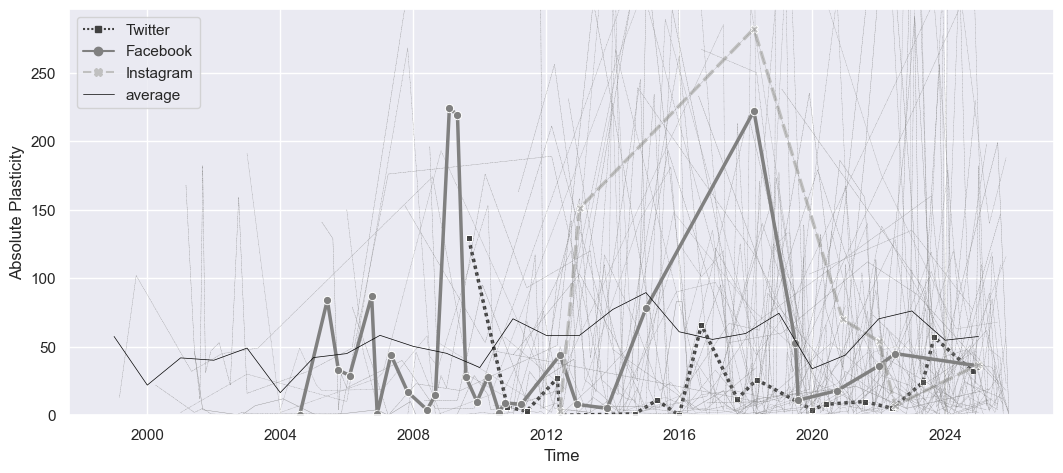

In [79]:
sns.set(rc={'figure.figsize':(12.7,5.27)})
platforms = ['twitter','fb','instagram']
#platforms = ['Google']#,'YouTube']
#platforms = ['PayPal','Venmo']
df_plat = result_df[result_df.platform.isin(platforms)]
variable = 'plasticity' #'rel_copied' #'rel_deletions' # 'plasticity'
from collections import OrderedDict

df_plat.replace({'platform': OrderedDict([('twitter', 'Twitter'),('fb', 'Facebook'),  ('instagram', 'Instagram')])}, inplace=True)

g= sns.lineplot(x=df_plat.index,y=variable,
                hue='platform',
                hue_order=['Twitter', 'Facebook', 'Instagram'],
                style="platform",
                markers=True,
                linewidth=2.5,
                legend=True,
                palette='gray',
                data=df_plat
            )
g.set(ylim=(0, None))




ax = sns.lineplot(x=result_df.index,y=variable,
                style="platform",
                linewidth=0.25,
                markers=False,
                legend=False,
                color='gray',
                data=result_df
            )

ax.set(
    xlabel="Time",
    ylabel="Absolute Plasticity",
)

# df_avg = result_df.groupby(result_df.index)[variable].mean()#.rolling(window=3, center=False).mean().reset_index(level=0, drop=True)
# sns.lineplot(x=df_avg.index,y=df_avg.values)
df_avg = result_df.groupby(result_df.year)[variable].mean()#.rolling(window=3, center=False).mean().reset_index(level=0, drop=True)
# convert integer year index to datetime (Jan 1 of that year)
df_avg_dt = df_avg.copy()
df_avg_dt.index = pd.to_datetime(df_avg_dt.index.astype(str), format='%Y')
df_avg_dt.index.name = 'date'

# quick check
df_avg_dt.head()
plast =sns.lineplot(x=df_avg_dt.index,y=df_avg_dt.values,linewidth=.5, color='black', label='average')
fig = plast.get_figure()
fig.savefig("figures/jels/Figure_10_gray.png", dpi=300, bbox_inches='tight')
# sns.lineplot(x=df_avg.index,y=df_avg.values,
#                 linewidth=.75,
#                 color='red',
#                 label='average'
#            )



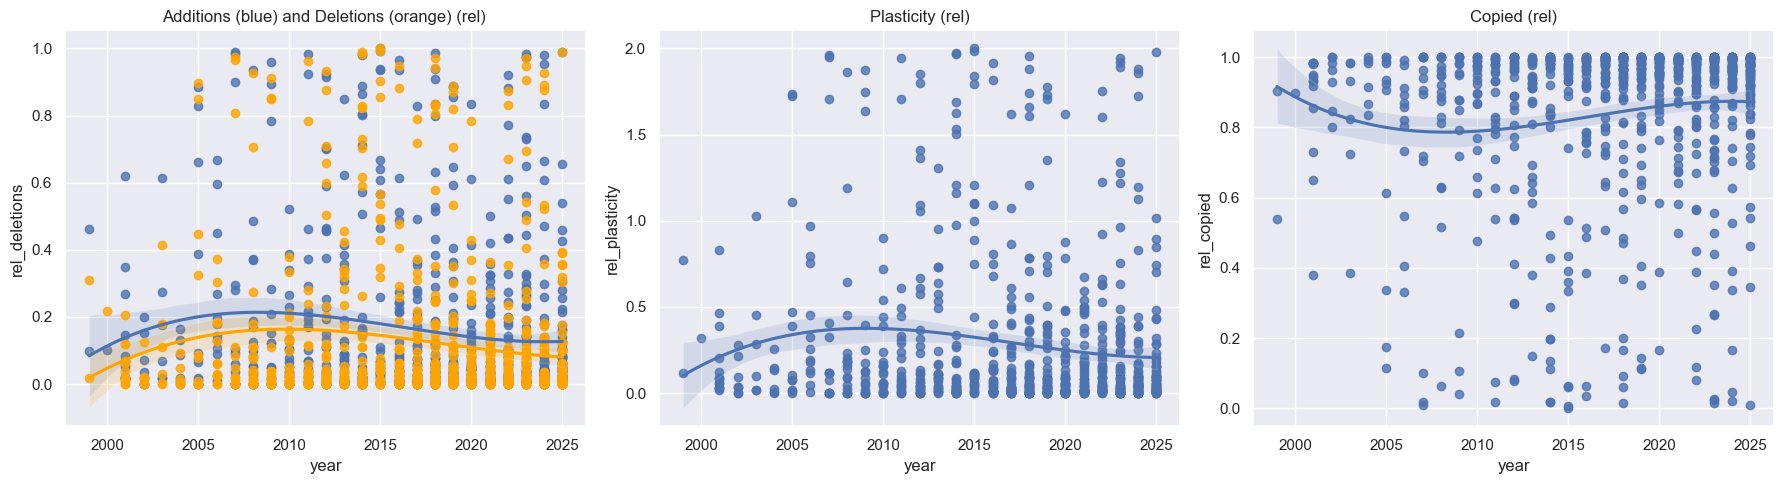

In [80]:
import matplotlib.pyplot as plt

order = 3

result_df['rel_plasticity'] = result_df['rel_additions'] + result_df['rel_deletions']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=result_df.astype({'year': int, 'rel_additions': float}), x='year', y='rel_additions', ax=axes[0], order=order)
sns.regplot(data=result_df.astype({'year': int, 'rel_deletions': float}), x='year', y='rel_deletions', ax=axes[0], color='orange', order=order)
axes[0].set_title('Additions (blue) and Deletions (orange) (rel) ')

sns.regplot(data=result_df.astype({'year': int, 'rel_plasticity': float}), x='year', y='rel_plasticity', ax=axes[1], order=order)
axes[1].set_title('Plasticity (rel)')

sns.regplot(data=result_df.astype({'year': int, 'rel_copied': float}), x='year', y='rel_copied', ax=axes[2], order=order)
axes[2].set_title('Copied (rel)')

plt.tight_layout()
plt.show()

<Axes: xlabel='rel_copied', ylabel='platform'>

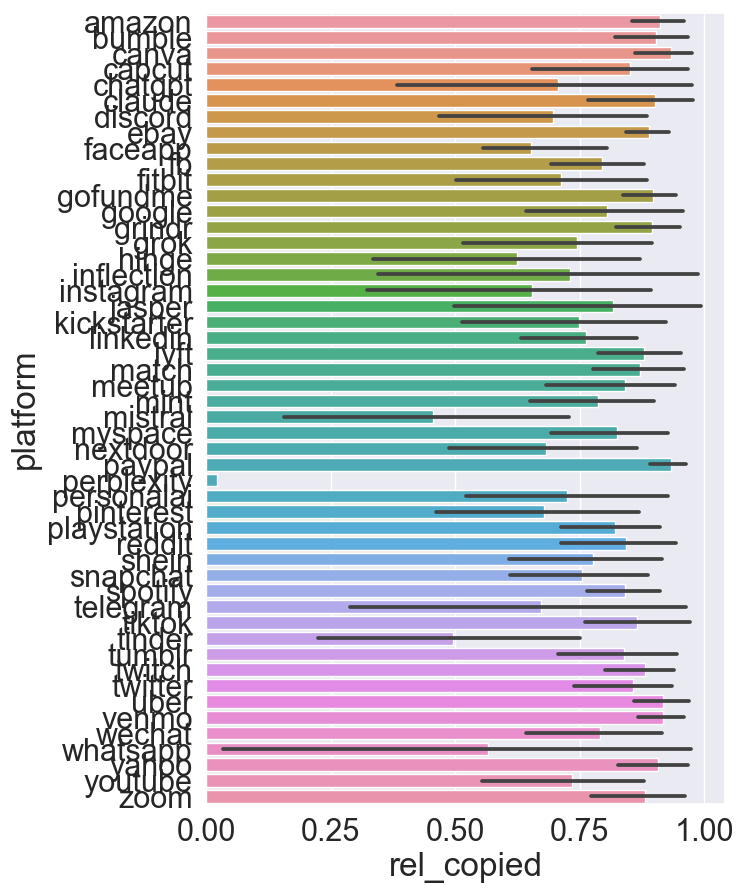

In [81]:
sns.set(rc={'figure.figsize':(6.7,10.27)})
sns.set(font_scale=2)
result_df= result_df.sort_values(by='platform')
sns.barplot(y='platform',x='rel_copied',data=result_df)

<Axes: xlabel='rel_additions', ylabel='platform'>

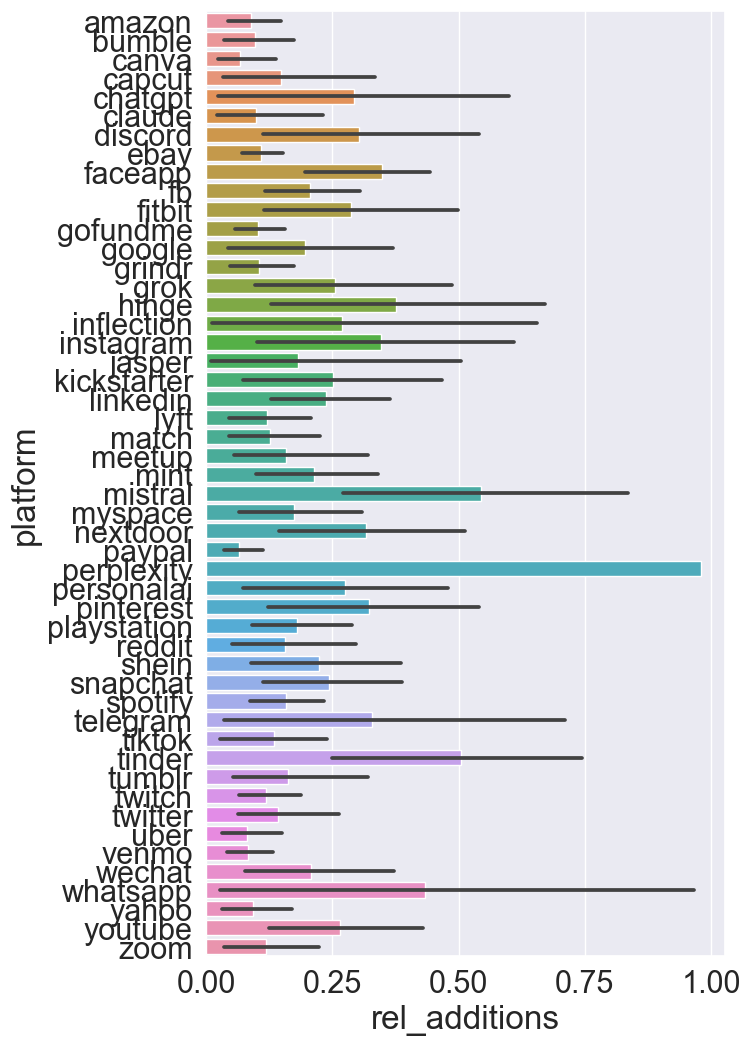

In [82]:
sns.set(rc={'figure.figsize':(6.7,12.27)})
sns.set(font_scale=2)
result_df= result_df.sort_values(by='platform')
sns.barplot(y='platform',x='rel_additions',data=result_df)

<Axes: xlabel='rel_deletions', ylabel='platform'>

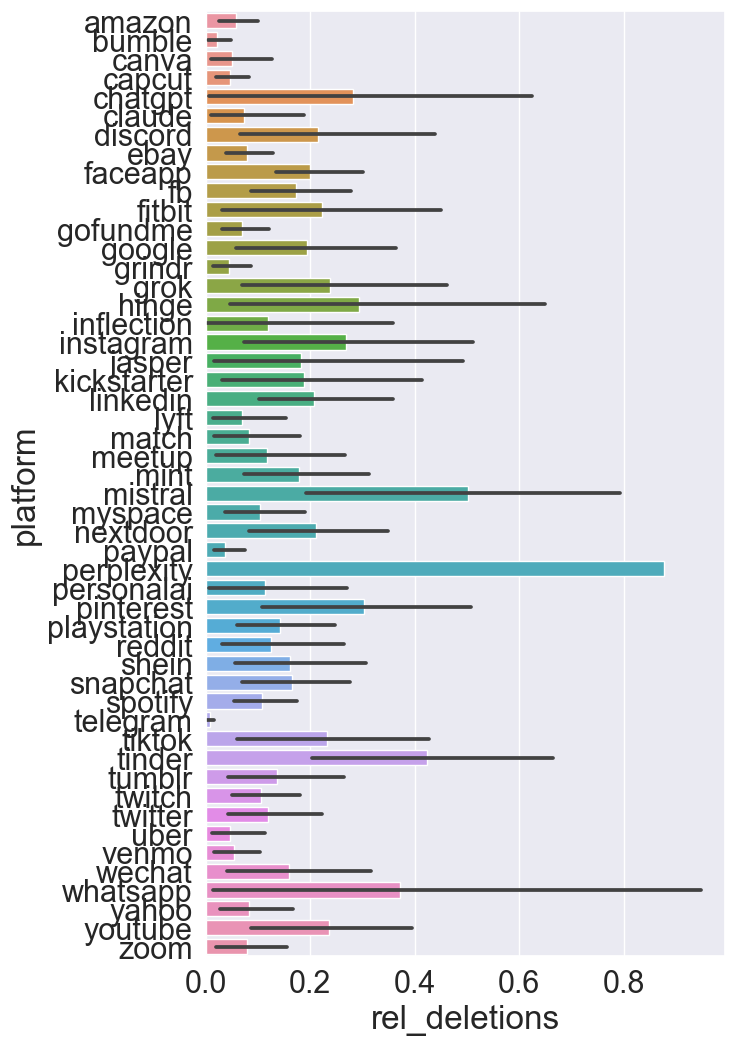

In [83]:
sns.set(rc={'figure.figsize':(6.7,12.27)})
sns.set(font_scale=2)
result_df= result_df.sort_values(by='platform')
sns.barplot(y='platform',x='rel_deletions',data=result_df)

# Clustering

In [84]:
# platforms = list(metadata.platform.unique())
# platforms.remove('PayPal')
# print(platforms)

In [85]:
threshold = .93
result_df = compare_timelines(metadata, embeddings, platforms,threshold)

100%|██████████| 7/7 [00:00<00:00, 40.82it/s]


In [86]:

new_length = 100  # Define the new length
interp_funcs = [interp1d(np.linspace(0, 1, len(p)), p) for p in result_df.past_projection.values]
matrix = np.array([interp(np.linspace(0, 1, new_length)) for interp in interp_funcs])
matrix.shape

(54, 100)

In [87]:
matrix_bin = (matrix > 0.93).astype(int)
matrix_bin.shape

(54, 100)

<Axes: ylabel='Frequency'>

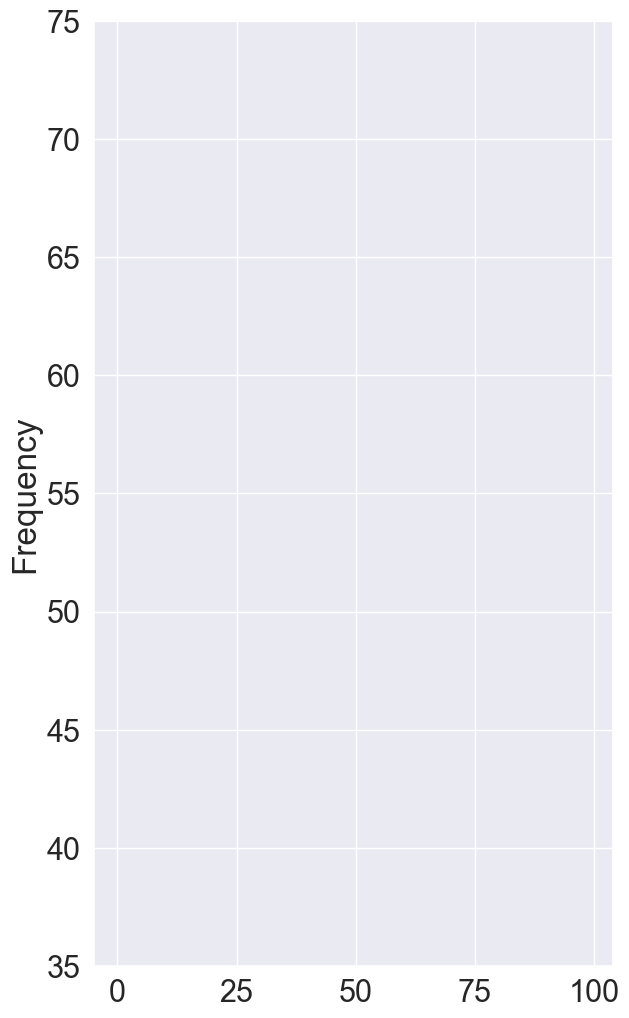

In [88]:
pd.Series(np.where(matrix_bin < 1)[1]).plot(kind='hist', bins=100, ylim=(35,75))

In [89]:
counts, division = np.histogram(np.where(matrix_bin < 1)[1], bins=np.linspace(0, 100, 101))

<Axes: >

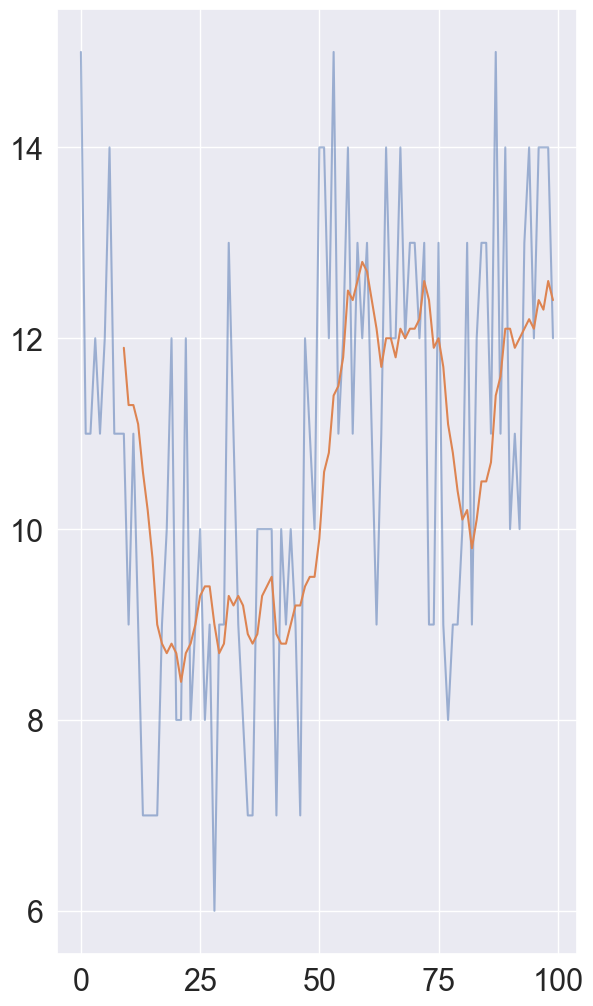

In [90]:
pd.Series(counts).plot(alpha=0.5)
pd.Series(counts).rolling(window=10).mean().plot()

<Axes: >

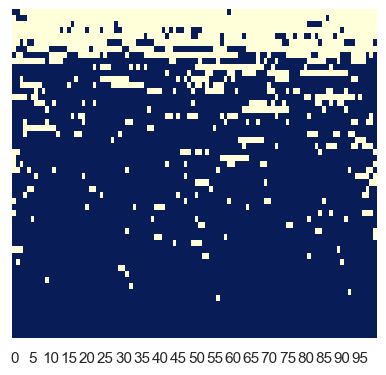

In [91]:

sorted_matrix = matrix_bin[np.argsort(matrix_bin.sum(axis=1))]
sns.set(rc={'figure.figsize':(4.7,4.27)})
sns.heatmap(sorted_matrix, cmap="YlGnBu", cbar=False, yticklabels=False)

/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


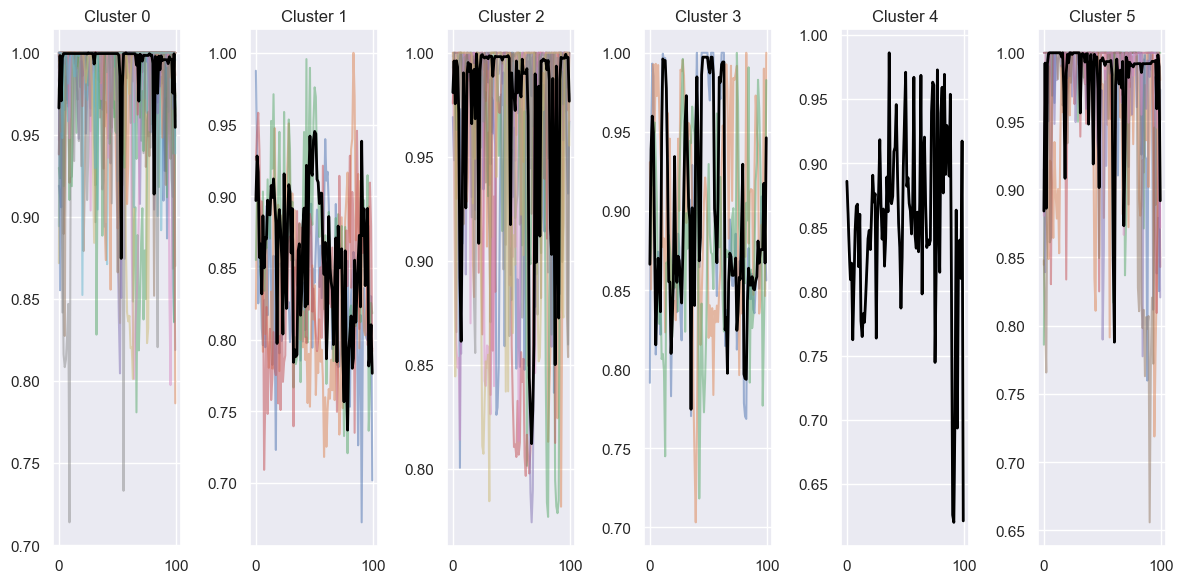

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans



# Number of clusters
n_clusters = 6

# DTW-based KMeans (soft-DTW is smoother and differentiable)
model = TimeSeriesKMeans(n_clusters=n_clusters, 
                         metric="dtw", 
                         max_iter=10, 
                         random_state=42)

labels = model.fit_predict(matrix)

# Print cluster assignments
# for i, label in enumerate(labels):
#     print(f"Timeline {i} -> Cluster {label}")

# Visualize clusters
plt.figure(figsize=(12, 6))
for cluster_id in range(n_clusters):
    plt.subplot(1, n_clusters, cluster_id + 1)
    for ts, lbl in zip(matrix, labels):
        if lbl == cluster_id:
            plt.plot(ts.ravel(), alpha=0.5)
    plt.plot(model.cluster_centers_[cluster_id].ravel(), color="black", linewidth=2)
    plt.title(f"Cluster {cluster_id}")
plt.tight_layout()
plt.show()


In [93]:

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(matrix)

In [94]:
freqs = dict(Counter(kmeans.labels_))
print(sum(freqs.values()))
freqs = {k: round(v/ sum(freqs.values()),2) for k,v in freqs.items()}
freqs

54


{0: 0.09, 1: 0.85, 2: 0.06}

<Axes: >

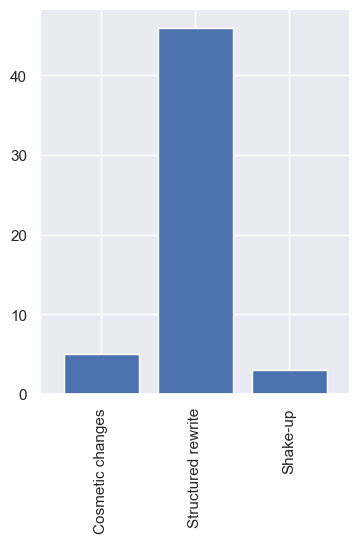

In [95]:
xlabs= {2: 'Shake-up',
0: 'Cosmetic changes',
1: 'Structured rewrite'}
new_dict = {xlabs[k]: v for k,v in dict(Counter(kmeans.labels_)).items()}
pd.Series(new_dict).plot(kind='bar',width=.8,figsize=(4,5))

In [96]:
pd.Series(new_dict) / sum(pd.Series(new_dict)) * 100

Cosmetic changes       9.259259
Structured rewrite    85.185185
Shake-up               5.555556
dtype: float64

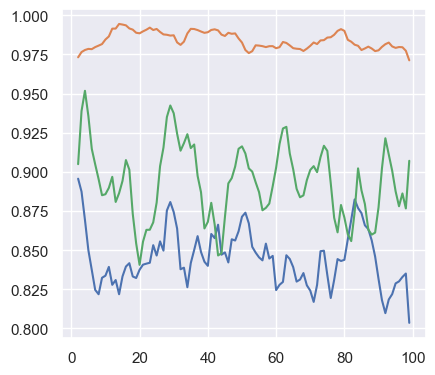

In [97]:
for i in range(n_clusters):
    pd.Series(np.mean(matrix[np.where(kmeans.labels_==i)],axis=0)).rolling(3).mean().plot()


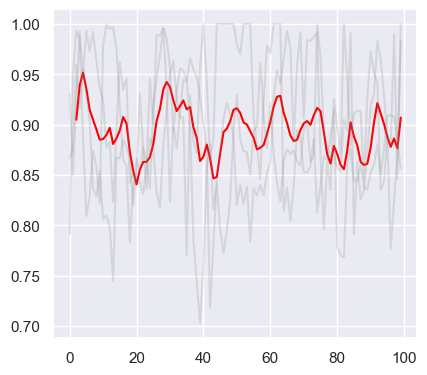

In [98]:
target_lab = 2
pd.Series(np.mean(matrix[np.where(kmeans.labels_==target_lab)],axis=0)).rolling(3).mean().plot(color='red')
for a in matrix[np.where(kmeans.labels_==target_lab)]:
    pd.Series(a).plot(color='grey', alpha=.2)

In [99]:
idx = np.where(kmeans.labels_==target_lab)[0][10]
print(idx)
sns.heatmap(result_df.iloc[idx].matrix)

IndexError: index 10 is out of bounds for axis 0 with size 3

In [ ]:
result_df['cluster_labels'] = kmeans.labels_
by_platform = result_df.groupby(['platform','cluster_labels'])['platform'].count()#.reset_index()
(by_platform.unstack(0) / by_platform.unstack(0).sum(axis=0)).T.plot(kind='bar', width=.75, figsize=(12,6))


In [ ]:
result_df['date'] = result_df.index
result_df['year'] = result_df['date'].apply(lambda x: x.year)
by_year = result_df.groupby(['year','cluster_labels'])['platform'].count()#.reset_index()
(by_year.unstack(0) / by_year.unstack(0).sum(axis=0)).T.fillna(.0).plot(kind='bar', width=.75, figsize=(16,6))


# Convergence

In [21]:
#results.pop('bumle')
metadata.replace({'platform': {'fb':'Facebook',
                               'tinder': 'Tinder',
                             'twitter':'Twitter',
                             'whatsapp':'WhatsApp',
                             'myspace':'MySpace',
                             'paypal':'PayPal',
                             'venmo':'Venmo',
                             'ebay':'eBay',
                             'match':'Match',
                             'hinge':'Hinge',
                             'bumble':'Bumble',
                             'grindr':'Grindr',
                             'faceapp': 'FaceApp',
                             'instagram':'Instagram',}}, inplace=True)

In [22]:
platforms = list(metadata.platform.unique()); platforms

['uber',
 'Twitter',
 'Bumble',
 'discord',
 'playstation',
 'kickstarter',
 'amazon',
 'mint',
 'pinterest',
 'Match',
 'MySpace',
 'google',
 'lyft',
 'claude',
 'spotify',
 'canva',
 'shein',
 'fitbit',
 'inflection',
 'nextdoor',
 'Grindr',
 'tumblr',
 'youtube',
 'Venmo',
 'eBay',
 'grok',
 'wechat',
 'perplexity',
 'Facebook',
 'capcut',
 'PayPal',
 'telegram',
 'reddit',
 'zoom',
 'FaceApp',
 'Hinge',
 'meetup',
 'Tinder',
 'chatgpt',
 'gofundme',
 'tiktok',
 'personalai',
 'twitch',
 'Instagram',
 'jasper',
 'snapchat',
 'mistral',
 'WhatsApp',
 'linkedin',
 'yahoo']

In [23]:
metadata['date'] = metadata.year.apply(lambda x:datetime.strptime(str(x), "%Y%m%d").date() )

# platform_t = 'instagram'
# platform_c = 'fb'

# platform_t = 'YouTube'
# platform_c = 'Google'

# platform_t = 'Venmo'
# platform_c = 'PayPal'



In [24]:

results = defaultdict(dict)
#platforms = ['Tinder',"Match",'Bumble','Grindr','Hinge']#,'Instagram']#,'Google','YouTube','PayPal','Venmo']
for i,j in tqdm(list(combinations(platforms,r=2))):
    #if i == 'Bumble' or j == 'Bumble':
    results[i][j] = convergence(metadata, embeddings, i,j,threshold=.93)
    results[j][i] = convergence(metadata, embeddings, j,i,threshold=.93)
    

100%|██████████| 1225/1225 [40:37<00:00,  1.99s/it] 


In [25]:
len(results.keys())

50

In [29]:
platform_target = 'Facebook'
#compare_to =[ ('green','Instagram'),('red','WhatsApp'),('orange','MySpace')]
#compare_to =[ ('darkgray','Instagram'),('black','WhatsApp'),('lightgray','MySpace')]


# platform_target = 'Google'
# compare_to = [('green','YouTube'),('red','Twitter')]

platform_target = 'PayPal'
#compare_to = [('green','Venmo'), ('red','eBay')]
#compare_to = [('gray','Venmo'), ('black','eBay')]

platform_target = 'Match'
compare_to = [('green','Bumble'), ('red','Hinge'),('orange','Grindr'),('blue','Tinder')] # ,('blue','faceapp')
#compare_to = [('lightgray','Bumble'), ('darkgray','Hinge'),('black','Grindr'),('black','Tinder')] # ,('blue','faceapp')

dataframes = []
for p in results.keys():
    if p != platform_target:
        df_ = results[platform_target][p][['date','similar','date_gap']].reset_index(drop=True)
        df_.loc[:,'platform'] = p
        dataframes.append(df_)


In [30]:
dfs = pd.concat(dataframes, axis=0)
#dfs = dfs[dfs.date != dfs.loc[dfs.platform=='hinge'].iloc[6].values[0]]
pivot = dfs.pivot_table(index=['date'], 
            columns=['platform'], values='similar')

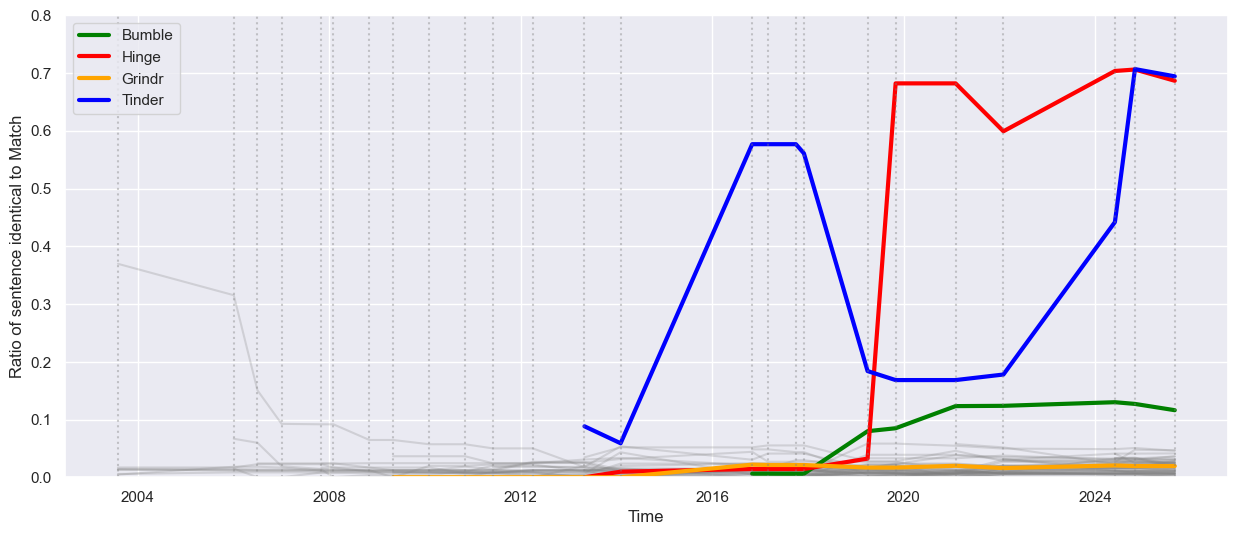

In [31]:


ax = pivot.plot(legend=False, figsize=(15,6), color=['grey'],  alpha=.25, ylim=(.0, .8))
for col,p in compare_to:
    pivot[p].plot(legend=True,  color=col, alpha=1., ax=ax, linewidth=3)
#     for xc in metadata[metadata.platform==p].date.unique():
#         if xc >= dfs.date.min() and xc <= dfs.date.max():
#             ax.axvline(x=xc, color=col, linestyle='--', alpha=.4)
        #ax.axvline(x=xc, color=col, linestyle='--', alpha=.2)

for xc in metadata[metadata.platform==platform_target].date.unique():
        if xc >= dfs.date.min() and xc <= dfs.date.max():
            ax.axvline(x=xc, color='grey', linestyle=':', alpha=.4)
        #ax.axvline(x=xc, color=col, linestyle='--', alpha=.2)

ax.set(
    xlabel="Time",
    ylabel=f"Ratio of sentence identical to {platform_target}",
)

conv = ax.get_figure()
conv.savefig(f"figures/jels/Figure_13.png", dpi=300, bbox_inches='tight')


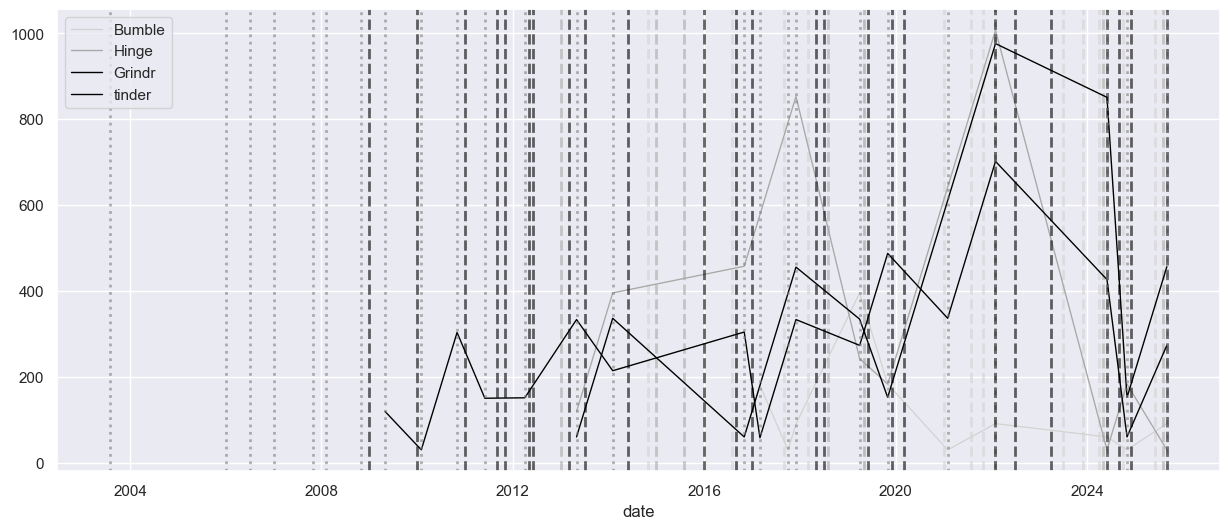

In [140]:
pivot = dfs[dfs.platform.isin([p for _, p in compare_to])].pivot_table(index=['date'], 
            columns=['platform'], values='date_gap')

ax = pivot.plot(legend=False, figsize=(15,6), color=['white'],  alpha=.25)
for col,p in compare_to:
    pivot[p].plot(legend=True,  color=col, alpha=1., ax=ax, linewidth=1)
    for xc in metadata[metadata.platform==p].date.unique():
        if xc >= dfs.date.min() and xc <= dfs.date.max():
            ax.axvline(x=xc, color=col, linestyle='--', alpha=.6,linewidth=2)
        #ax.axvline(x=xc, color=col, linestyle='--', alpha=.2)

for xc in metadata[metadata.platform==platform_target].date.unique():
        if xc >= dfs.date.min() and xc <= dfs.date.max():
            ax.axvline(x=xc, color='grey', linestyle=':', alpha=.6,linewidth=2)

(0.0, 0.8)

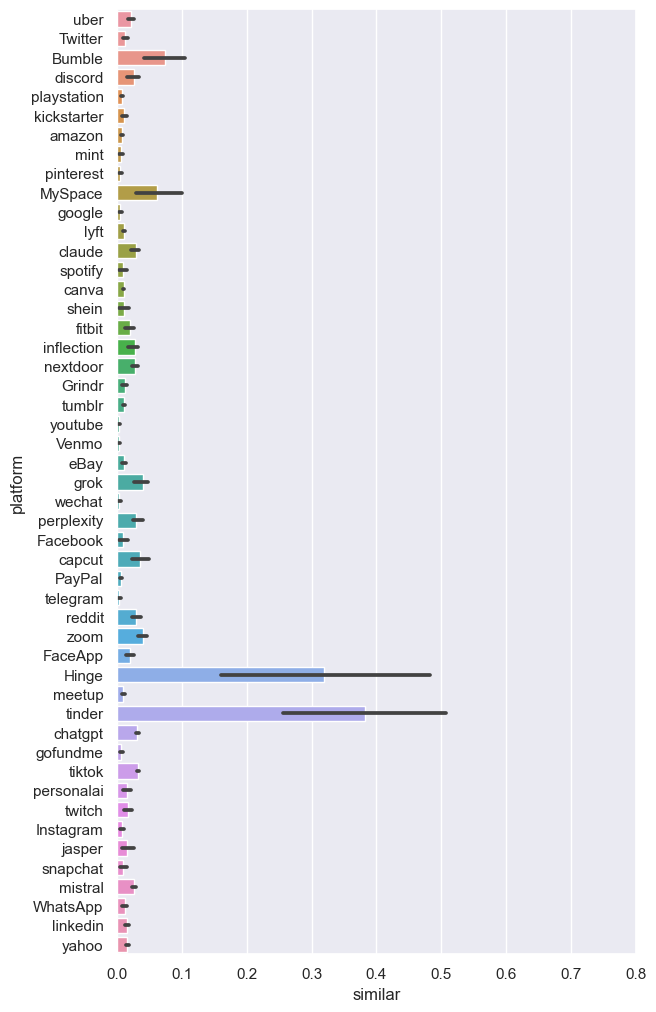

In [133]:
sns.set(rc={'figure.figsize':(6.7,12.27)})
axes =sns.barplot(y='platform',x='similar',data=dfs )
axes.set_xlim(0,.8)

<Axes: xlabel='date'>

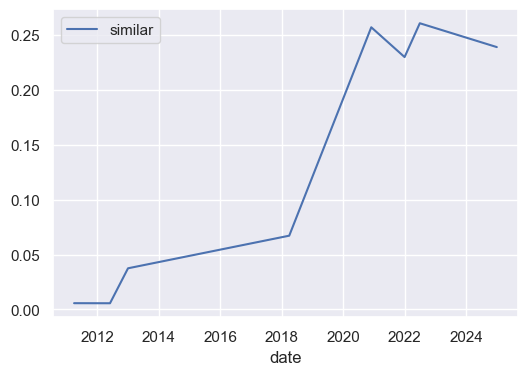

In [110]:
platform_t = 'instagram'
platform_c = 'fb'

# platform_t = 'YouTube'
# platform_c = 'Google'

# platform_t = 'Venmo'
# platform_c = 'PayPal'
results[platform_t][platform_c][['date','similar']].plot(x='date',y='similar',kind='line',figsize=(6,4))


In [ ]:
rows = []
for i,j in tqdm(results.items()):
    for k,v in j.items():
        try:
            # try to figure out why this exception occurs
            rows.append([i,k,list(v['mean'].values)])
        except Exception as  e:
            print(i,k,e)
            continue
conv_df = pd.DataFrame(rows,columns=['source','target','mean'])


In [ ]:
sims = [s for a in  
           conv_df[(conv_df.source=='Twitter') & (conv_df.target.isin(['FB', 'Instagram','LinkedIn']))]['mean'].values
           for s in a
           ]
pd.Series(sims).plot(kind='density', color='blue', alpha=.5)

sims = [s for a in  
           conv_df[(conv_df.source=='FB') & (conv_df.target.isin(['Twitter', 'Instagram','LinkedIn']))]['mean'].values
           for s in a
           ]
pd.Series(sims).plot(kind='density', color='blue', alpha=.5)

sims = [s for a in  
           conv_df[(conv_df.source=='Instagram') & (conv_df.target.isin(['Twitter', 'FB','LinkedIn']))]['mean'].values
           for s in a
           ]
pd.Series(sims).plot(kind='density', color='blue', alpha=.5)

sims = [s for a in  
           conv_df[(conv_df.source=='LinkedIn') & (conv_df.target.isin(['Twitter', 'FB','Instagram']))]['mean'].values
           for s in a
           ]
pd.Series(sims).plot(kind='density', color='blue', alpha=.5)

sims = [s for a in  
           conv_df[(conv_df.source=='Twitter') & (conv_df.target.isin(['PayPal', 'Venmo']))]['mean'].values
           for s in a
           ]
pd.Series(sims).plot(kind='density',color='orange', alpha=.5)

sims = [s for a in  
           conv_df[(conv_df.source=='FB') & (conv_df.target.isin(['PayPal', 'Venmo']))]['mean'].values
           for s in a
           ]
pd.Series(sims).plot(kind='density',color='orange', alpha=.5)

sims = [s for a in  
           conv_df[(conv_df.source=='Instagram') & (conv_df.target.isin(['PayPal', 'Venmo']))]['mean'].values
           for s in a
           ]
pd.Series(sims).plot(kind='density',color='orange', alpha=.5)

sims = [s for a in  
           conv_df[(conv_df.source=='LinkedIn') & (conv_df.target.isin(['PayPal', 'Venmo']))]['mean'].values
           for s in a
           ]
pd.Series(sims).plot(kind='density',color='orange', alpha=.5)

## Get similar sentences across platforms

In [ ]:
platform_t,platform_c = 'Google','YouTube'
threshold = .875

dates_t = sorted(metadata[metadata.platform==platform_t].date.unique())
dates_c = sorted(metadata[metadata.platform==platform_c].date.unique())
resultList = []

for i,d in enumerate(dates_t):
        days_delta = [(dc,(dc - d).days) for dc in dates_c]
        dc, days = negative_closest_to_zero(days_delta)
        if dc:

            metadata[(metadata.date == dc) & (metadata.platform==platform_c)]

            idx_1 = list(metadata[(metadata.platform==platform_t) & (metadata.date ==d)].index)
            idx_2 = list(metadata[(metadata.platform==platform_c) & (metadata.date ==dc)].index)
            #print(i,len(idx_1),len(idx_2),d,dc, days)
            mult = 1 - sp.distance.cdist(embeddings[idx_1,:], embeddings[idx_2,:], 'cosine')
            # x = np.apply_along_axis(np.max,0,mult)
            # x_sent = np.array(idx_2)[np.where(x > threshold)[0]]

            # y = np.apply_along_axis(np.max,1,mult)
            # y_sent = np.array(idx_1)[np.where(y  > threshold)[0]]
            
            for k,l in list(zip(*np.where(mult > threshold))):
                resultList.append(
                    [d,dc,
                    mult[k,l],
                    metadata.iloc[idx_1[k]].platform,
                    metadata.iloc[idx_1[k]].sentence,
                    metadata.iloc[idx_2[l]].platform,
                    metadata.iloc[idx_2[l]].sentence,])
     

In [ ]:
df_results = pd.DataFrame(resultList, columns=[f'date_1_{platform_t}',f'date_2_{platform_c}','similar','platform_t','sentence_t','platform_c','sentence_c'])
df_results.shape

In [ ]:
df_results.similar.plot(kind='hist',bins=100)

In [ ]:
dfs = []
for s,e in [(0.9,0.95),(0.95,0.975)]: # (0.8,0.9),
    dfs.append(df_results[df_results.similar.between(s,e)].sample(10))
dfs = pd.concat(dfs, axis=0, ignore_index=True)
dfs['label'] = 0
dfs.to_csv('pairs_to_annotate_round_2.csv',index=False)

In [ ]:
df_results[df_results.similar >= .8].to_csv('similar_sentences_Google_Google_80.csv',index=False)

In [ ]:
df_results.sort_values(by='similar',ascending=False).drop_duplicates(subset=['date_1_FB','date_2_Instagram','sentence_t'],keep='first')

In [ ]:
df_results.groupby('date_1_FB')['platform_t'].size().plot()

# Fin.